# Text-Segmentierung Klassifkationsmodell Neuronale Netzwerke

Training und Test eines Klassifikationsodells zur Text-Segmentierung mittels maschinellen Lernens bzw. Deep-Learing und Verwendung Neuronaler Netzwerke.

**Voraussetzungen**

Environment: model_nn

Zur Erstellung des Datensatzes für das Training muss für die verwendeten PDF-Dokumente zurvor die Vorverarbeitung und Erstellung der Dataframes über das Notebook Preparation.ipynb ausgeführt werden.



## Setup

### Pakete laden

In [1]:
import config

import os
os.environ["KERAS_BACKEND"] = "torch"

import time

import regex as re

import pandas as pd
import numpy as np

from openai import OpenAI

import keras

from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, recall_score
from sklearn.utils import compute_class_weight

from plotly.subplots import make_subplots
import plotly.graph_objects as go

from util.datasetprocessor import DatasetProcessor
from util.pdfprocessor import PDFProcessor
from util.helper import Helper
from util.px import PX

### Variablen+Funktionen

In [2]:
# Klassen-Label
labels = ['false', 'true']

### Daten laden

In [3]:
# Answers
answers = pd.read_json(f'{config.dataset["path"]}answers.json', orient='index', dtype_backend='numpy_nullable').rename(columns={0: "answer"})
# Queries
queries = pd.read_json(f'{config.dataset["path"]}queries.json', orient='index', dtype_backend='numpy_nullable')
# Relations
qrels = pd.read_json(f'{config.dataset["path"]}qrels.json', orient='index', dtype_backend='numpy_nullable')

# PDF URLs
#pdf_urls = pd.read_json(f'{config.dataset["path"]}pdf_urls.json', orient='index', dtype_backend='numpy_nullable').rename(columns={0: "pdf_urls"})

pdf_urls_clean = pd.read_json(f'{config.dataset["path"]}pdf_urls_clean.json', orient='index', dtype_backend='numpy_nullable')#.rename(columns={0: "pdf_urls"})
pdf_urls = pdf_urls_clean.loc[pdf_urls_clean.values]

### Fragen selektieren

Fragen mit Quelle "Text" und "Text-Tabelle" und mindestens acht Wörtern in der Referenz-Antwort (Fragen mit kurzen Antworten wie "yes" ausschließen) für Ausführung selektieren

In [4]:
# Fragen und Antworten über Index joinen
queries_answers = queries.merge(answers, how='inner', left_index=True, right_index=True)

# Anzahl Wörter der Fragen 
queries_answers['answer_replace'] = queries_answers['answer'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True)
queries_answers['answer_word_count'] = queries_answers['answer_replace'].str.split(' ').str.len()

# Fragen mit source=text|text-table und answer_word_count>=8
queries_text_text_table = queries_answers.loc[((queries_answers['source'] == 'text') | (queries_answers['source'] == 'text-table')) & (queries_answers['answer_word_count'] >= 8)]

# 1/4 der Fragen selektieren
queries_text_text_table = queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42)

### Neuronales Netzwerk

Neuronales Netzwerk (Layer+Neuronen), Optimizer und Scheduler definieren und Modell kompilieren.

In [5]:
def model_init(n1, n2, learning_rate=1e-03, weight_decay=None):
    # Seed setzen (Reproduzierbarkeit)
    keras.utils.set_random_seed(42)

    # Netzwerk erstellen
    
    # Sequentiell Layer hinzufügen
    model = keras.models.Sequential()
    
    # Weight Initializer
    initializer = keras.initializers.RandomUniform(minval=-0.5, maxval=0.5)
    
    # Input layer mit 18 Neuronen (Anzahl Spalten Datensatz ohne Zielvariable)
    model.add(keras.Input(shape=(X_train.columns.shape[0],)))
    
    # Daten normalisieren
    model.add(keras.layers.BatchNormalization())
    
    # Dropout Layer
    #model.add(keras.layers.Dropout(0.2))
    
    # Hidden Layer
    model.add(keras.layers.Dense(n1,# / 3
        #input_dim=2, 
        kernel_initializer=initializer, 
        bias_initializer=initializer,
        activation='relu',#sigmoid
        use_bias=True))
    
    # Hidden Layer
    model.add(keras.layers.Dense(n2,
        kernel_initializer=initializer,
        bias_initializer=initializer,
        activation='relu',
        use_bias=True))
    
    # Output layer
    model.add(keras.layers.Dense(2,
        kernel_initializer=initializer, 
        bias_initializer=initializer,
        activation='softmax', # softmax for a binary classification
        #activation='sigmoid',
        use_bias=True))

    # Optimizer
    #optimizer = tf.keras.optimizers.SGD(learning_rate=0.075)
    #optimizer = keras.optimizers.RMSprop(learning_rate=0.075) # use Adam rather then RMSprop.
    
    decay_steps = 1000
    initial_learning_rate = 0.0
    warmup_steps = 1000
    
    cosine_decay_scheduler = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate,
        decay_steps, 
        alpha=0.0,
        name="CosineDecay",
        warmup_target=learning_rate,
        warmup_steps=warmup_steps
    )

    optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate,#cosine_decay_scheduler
        weight_decay=weight_decay,
        #gradient_accumulation_steps=2
    )

    # Modell compilieren
    model.compile(
        optimizer=optimizer,#'adam'
        loss='sparse_categorical_crossentropy', 
        metrics=['accuracy']
    )

    return model

In [6]:
#model = init_model()
#model.summary()

## Parameter-Test

Test verschiedener Werte für Modell-Parameter learing_rate, batch_size und Anzahl der Neuronen für Layer sowie Epochen für Training.

Für das Training der Modelle werden die 622 der insgesamt 867 Dokumente verwendet, auf welche sich die gewählten 397 Fragen für die Generierung der Antworten nicht beziehen. 

#### Dokumente selektieren

In [6]:
# Beziehung zwischen Frage und Dokument über qrels
# qrels/Dokumente für alle Fragen wählen
qrels_select = qrels.loc[queries_text_text_table.index]
# qrels ausschließen, für die Dokumente (doc_id) nicht in pdf_urls (index)
qrels_select = qrels_select.drop(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index)

#### Datensatz erstellen

In [7]:
# Datensatz erstellen+shuffle
df = DatasetProcessor.dataset_create(
    config.dataset['path'], 
    pdf_urls.loc[~pdf_urls.index.isin(qrels_select['doc_id'].unique())],
    embedding_dimension=768#768
)#.sample(frac=1, axis=0, random_state=42)

2407.01528v3
2412.00651v1
2411.00713v1
2402.03953v4
2408.08383v2
2410.19011v2
2411.03915v2
2404.18884v2
2410.08709v3
2409.19777v2
2405.02054v2
2412.18222v1
2411.12363v3
2411.18627v2
2403.18177v2
2409.13467v3
2407.11336v2
2411.15638v2
2406.04991v2
2408.16891v2
2410.00158v1
2412.14784v3
2412.01100v2
2412.12639v3
2410.20081v3
2411.02558v1
2406.18046v2
2411.07216v2
2407.11758v1
2402.05967v7
2412.12919v2
2406.01756v2
2403.15076v1
2406.18345v3
2409.20319v2
2407.18909v1
2412.06412v2
2407.04378v2
2412.15576v4
2406.10612v1
2412.11037v2
2410.10474v1
2404.17736v3
2412.05430v1
2408.09648v4
2411.08072v1
2405.18213v3
2412.16067v1
2407.07368v3
2404.18869v2
2403.13637v6
2412.17780v3
2410.03930v3
2412.20019v2
2412.00886v2
2411.14471v1
2412.00566v2
2411.01864v1
2412.14029v2
2411.02807v4
2411.18473v2
2402.16901v2
2501.00225v2
2405.05881v2
2404.13877v2
2410.23473v2
2411.12193v2
2412.18252v2
2405.06851v2
2412.04313v2
2405.12292v3
2410.16441v2
2402.07135v2
2408.06427v2
2409.12516v1
2403.11738v3
2410.10304v2

#### Train-/Test/Eval-Set erstellen

Datensatz für Training in Train-, Test- und Eval-Set teilen.

Gesamten Datensatz im Verhältnis 80/20 in Train-/Test-Set teilen. Train-Set anschließend in Train- und Eval-Set für Bewertung der Modell-Ergebnisse während des Trainings im Verhältnis 80/20 teilen

In [8]:
# Train-/Test-/Eval-Set
X_train, X_test, y_train, y_test = DatasetProcessor.dataset_split(df.drop(columns=['boundary']), df['boundary'], fraction_test=0.2, seed=42)
X_train, X_eval, y_train, y_eval = DatasetProcessor.dataset_split(X_train, y_train, fraction_test=0.2, seed=42)

#### Modell trainieren

In [26]:
# Epochen für Training
epochs = 2

#for epochs in [1, 2, 3, 4, 5]:#Epochs
#for n in [8, 16, 32, 64, 128]:#Neuronen/Layer
#for learing_rate in [0.1, 0.001, 0.0001, 0.00001, 0.000001]:#learing_rate
#for batch_size in [8, 16, 32, 64]:#batch_size

# Modell initialisieren
model = model_init(
    n1=64,#n
    n2=8,#n
    learning_rate=1e-03,#learning_rate
    weight_decay=None
)

# Modell trainieren
history = model.fit(
    X_train.to_numpy(dtype=float),
    y_train.to_numpy(dtype=int),
    verbose=True,
    epochs=epochs,
    batch_size=16,#batch_size
    validation_data=(X_eval.to_numpy(dtype=float),y_eval.to_numpy(dtype=int)),
    #class_weight={'0':class_weight[0], '1':class_weight[1]}
)

Epoch 1/2
7889/7889 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9762 - loss: 0.0705 - val_accuracy: 0.9878 - val_loss: 0.0387
Epoch 2/2
7889/7889 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9894 - loss: 0.0328 - val_accuracy: 0.9889 - val_loss: 0.0331


In [15]:
# Epochen 1
#7889/7889 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9762 - loss: 0.0705 - val_accuracy: 0.9878 - val_loss: 0.0387

# Epochen 2
#7889/7889 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9762 - loss: 0.0705 - val_accuracy: 0.9878 - val_loss: 0.0387
#7889/7889 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9894 - loss: 0.0328 - val_accuracy: 0.9889 - val_loss: 0.0331

# Epochen 3
#7889/7889 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9762 - loss: 0.0705 - val_accuracy: 0.9878 - val_loss: 0.0387
#7889/7889 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9894 - loss: 0.0328 - val_accuracy: 0.9889 - val_loss: 0.0331
#7889/7889 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9921 - loss: 0.0239 - val_accuracy: 0.9895 - val_loss: 0.0353

# Epochen 4
#7889/7889 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9762 - loss: 0.0705 - val_accuracy: 0.9878 - val_loss: 0.0387
#7889/7889 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9894 - loss: 0.0328 - val_accuracy: 0.9889 - val_loss: 0.0331
#7889/7889 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9921 - loss: 0.0239 - val_accuracy: 0.9895 - val_loss: 0.0353
#7889/7889 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9936 - loss: 0.0176 - val_accuracy: 0.9890 - val_loss: 0.0382

# Epochen 5
#7889/7889 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9762 - loss: 0.0705 - val_accuracy: 0.9878 - val_loss: 0.0387
#7889/7889 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9894 - loss: 0.0328 - val_accuracy: 0.9889 - val_loss: 0.0331
#7889/7889 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9921 - loss: 0.0239 - val_accuracy: 0.9895 - val_loss: 0.0353
#7889/7889 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9936 - loss: 0.0176 - val_accuracy: 0.9890 - val_loss: 0.0382
#7889/7889 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9950 - loss: 0.0140 - val_accuracy: 0.9895 - val_loss: 0.0511

Mit einem Netzwerk, welches aus zwei Layern mit 64 und 8 Neuronen besteht sowie einer Learning-Rate von 1e-03 und Batch-Size von 16 wurde das beste Ergebnis erzielt. Bei steigender Anzahl an Epochen für das Training, ist der Loss für die Trainingsdaten kontinuierlich gesunken. Für die Validierungsdaten ist dieser bis zu einer Anzahl von zwei Epochen ebenfalls gesunken, steigt ab der dritten Epoche aber wieder an. Es wird vermutet, dass das Modell nach 3 Epochen austrainiert ist und ein weiteres Training zu einer Überanpassung führt.

### Vorhersage

In [27]:
y_pred = model.predict(X_test.to_numpy(dtype=float))

1231/1231 ━━━━━━━━━━━━━━━━━━━━ 1s 938us/step


### Scores

In [28]:
print(f'accuracy: {accuracy_score(y_test.to_numpy(dtype=int), y_pred.argmax(1)):.4f}')
print(f'precision: {precision_score(y_test.to_numpy(dtype=int), y_pred.argmax(1)):.4f}')
print(f'recall: {recall_score(y_test.to_numpy(dtype=int), y_pred.argmax(1)):.4f}')

accuracy: 0.9901
precision: 0.9330
recall: 0.8826


In [ ]:
# Epochen 1
#accuracy: 0.9881
#precision: 0.9223
#recall: 0.8562

# Epochen 2
#accuracy: 0.9901
#precision: 0.9330
#recall: 0.8826

# Epochen 3
#accuracy: 0.9902
#precision: 0.9545
#recall: 0.8622

# Epochen 4
#accuracy: 0.9893
#precision: 0.9412
#recall: 0.8590

# Epochen 5
#accuracy: 0.9894
#precision: 0.9684
#recall: 0.8350

Die höhchste Accuracy mit 0.9902 wurde bei einem Training des Modells mit 3 Epochen erzielt.

## Cross-Validation

Durchführung einer Cross-Validation zur Prüfung der Fähigkeit zur Generalisierung des Verfahrens mit den verwendeten Daten.

Angewendet wird eine 5-Fold Bootstrap Cross-Validation (Stichproben aus Datensatz ziehen mit zurücklegen).

### Dokumente selektieren

In [6]:
# Beziehung zwischen Frage und Dokument über qrels
# qrels/Dokumente für alle Fragen wählen
qrels_select = qrels.loc[queries_text_text_table.index]
# qrels ausschließen, für die Dokumente (doc_id) nicht in pdf_urls (index)
qrels_select = qrels_select.drop(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index)

# PDF URLs wählen, deren Index nicht die Dokumente enthält, auf welche sich die Fragen beziehen
pdf_urls_select = pdf_urls.loc[~pdf_urls.index.isin(qrels_select['doc_id'].unique())]

### Datensatz erstellen

Datensatz aus gewählten Dokumenten mit Dimension 768 für Embedding-Vektoren erstellen

In [7]:
#time_start = time.time()

# Datensatz erstellen+shuffle
df = DatasetProcessor.dataset_create(
    config.dataset['path'], 
    pdf_urls_select,#.sample(n=round(pdf_urls_select.shape[0] / 3), axis=0, random_state=42),
    embedding_dimension=768
)#.sample(frac=1, axis=0, random_state=42)

#print(time.time() - time_start)

2407.01528v3
2412.00651v1
2411.00713v1
2402.03953v4
2408.08383v2
2410.19011v2
2411.03915v2
2404.18884v2
2410.08709v3
2409.19777v2
2405.02054v2
2412.18222v1
2411.12363v3
2411.18627v2
2403.18177v2
2409.13467v3
2407.11336v2
2411.15638v2
2406.04991v2
2408.16891v2
2410.00158v1
2412.14784v3
2412.01100v2
2412.12639v3
2410.20081v3
2411.02558v1
2406.18046v2
2411.07216v2
2407.11758v1
2402.05967v7
2412.12919v2
2406.01756v2
2403.15076v1
2406.18345v3
2409.20319v2
2407.18909v1
2412.06412v2
2407.04378v2
2412.15576v4
2406.10612v1
2412.11037v2
2410.10474v1
2404.17736v3
2412.05430v1
2408.09648v4
2411.08072v1
2405.18213v3
2412.16067v1
2407.07368v3
2404.18869v2
2403.13637v6
2412.17780v3
2410.03930v3
2412.20019v2
2412.00886v2
2411.14471v1
2412.00566v2
2411.01864v1
2412.14029v2
2411.02807v4
2411.18473v2
2402.16901v2
2501.00225v2
2405.05881v2
2404.13877v2
2410.23473v2
2411.12193v2
2412.18252v2
2405.06851v2
2412.04313v2
2405.12292v3
2410.16441v2
2402.07135v2
2408.06427v2
2409.12516v1
2403.11738v3
2410.10304v2

In [9]:
#(df.isna()).all().unique()

array([False])

### Splits erstellen

Erstellung von 5 Splits und wechselseitiges Training mit 4 Splits und Test mit einem Split.

In [8]:
# Anzahl Splits
num_splits=5

# Splits erzeugen
splits = DatasetProcessor.dataset_cross_validation(df, num_splits=num_splits)

Für den Aufbau des neuronalen Netzwerks wurde mit zwei Schichten mit 64 und 8 Neuronen, einer Batch-Size von 16 und einer learning_rate von 1e-3 die besten Ergebnisse erzielt.

In [9]:
# Listen für Werte der Metriken
metrics = {'accuracy': [], 'recall': [], 'precision': []}

# Merkmale
X = df.drop(columns=['boundary'])
# Zielvariable
y = df['boundary']

epochs = 3

# Über Splits iterieren
for i in range(num_splits):
    # Beobachtungen für Train-/Test-Split aus Datensatz selektieren
    X_train, X_test, y_train, y_test = X.loc[~splits[i]], X.loc[splits[i]], y.loc[~splits[i]], y.loc[splits[i]]
    # Train-Set in Train-/Eval-Set splitten
    X_train, X_eval, y_train, y_eval = DatasetProcessor.dataset_split(X_train, y_train, fraction_test=0.2, seed=42)

    # Modell initialisieren
    model = model_init(
        n1=64,
        n2=8,
        learning_rate=1e-03,
        weight_decay=None
    )
    
    # Modell trainieren
    history = model.fit(
        X_train.to_numpy(dtype=float),
        y_train.to_numpy(dtype=int), #
        verbose=True,
        epochs=epochs,
        batch_size=16,
        validation_data=(X_eval.to_numpy(dtype=float),y_eval.to_numpy(dtype=int)),
        #class_weight={'0':class_weight[0], '1':class_weight[1]},
        #maxIter=600
    )

    # Vorhersage
    yp = model.predict(X_test.to_numpy(dtype=float))
    # Scores berechnen
    metrics['accuracy'].append(accuracy_score(y_test.to_numpy(dtype=int), yp.argmax(1)))
    metrics['recall'].append(recall_score(y_test.to_numpy(dtype=int), yp.argmax(1)))
    metrics['precision'].append(precision_score(y_test.to_numpy(dtype=int), yp.argmax(1)))

Epoch 1/3
7889/7889 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9743 - loss: 0.0777 - val_accuracy: 0.9876 - val_loss: 0.0394
Epoch 2/3
7889/7889 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9890 - loss: 0.0337 - val_accuracy: 0.9886 - val_loss: 0.0347
Epoch 3/3
7889/7889 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9920 - loss: 0.0244 - val_accuracy: 0.9903 - val_loss: 0.0354
1231/1231 ━━━━━━━━━━━━━━━━━━━━ 1s 932us/step
Epoch 1/3
7892/7892 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9747 - loss: 0.0774 - val_accuracy: 0.9861 - val_loss: 0.0422
Epoch 2/3
7892/7892 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.9888 - loss: 0.0343 - val_accuracy: 0.9887 - val_loss: 0.0366
Epoch 3/3
7892/7892 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9919 - loss: 0.0248 - val_accuracy: 0.9898 - val_loss: 0.0377
1229/1229 ━━━━━━━━━━━━━━━━━━━━ 1s 932us/step
Epoch 1/3
7893/7893 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9742 - loss: 0.0771 - val_accuracy: 0.9875 - val_loss: 0.0378


In [ ]:
print(f'accuracy: {np.mean(metrics["accuracy"])}, recall: {np.mean(metrics["recall"])}, precision: {np.mean(metrics["precision"])}')

# embedding dimension 384 1/1
#accuracy: 0.9873707248370767, recall: 0.8350743789285191, precision: 0.9248672288772841

# 512 1/1
#accuracy: 0.9885849128987679, recall: 0.8593034259215745, precision: 0.9244768331387341

# 768 1/1
#accuracy: 0.989505351335116, recall: 0.8693888797562026, precision: 0.9321631671388614

# 768 1/3
#accuracy: 0.9874134559883991, recall: 0.8512409975033723, precision: 0.917734011104239

# 1024 1/3
#accuracy: 0.9871971448795753, recall: 0.8623506272908763, precision: 0.9051420925714829

# 2048 1/3
#accuracy: 0.9892174607160124, recall: 0.8840738053557302, precision: 0.9200404542578131

| V-Dim | Datensatz | accuracy | recall | precision |
| - | - | - | - | - |
| 384 | 1/1 | 0.9873707248370767 | 0.8350743789285191 | 0.9248672288772841 |
| 512 | 1/1 | 0.9885849128987679 | 0.8593034259215745 | 0.9244768331387341 |
| 768 | 1/1 | 0.989505351335116 | 0.8693888797562026 | 0.9321631671388614 |
| 768 | 1/3 | 0.9874134559883991 | 0.8512409975033723 | 0.917734011104239 |
| 1024 | 1/3 | 0.9871971448795753 | 0.8623506272908763 | 0.9051420925714829 |
| 2048 | 1/3 | 0.9892174607160124 | 0.8840738053557302 | 0.9200404542578131 |

Für das Neuronale Netzwerk wurde bei der Cross-Validation unter Nutzung der Emebdding-Dimension 768 und der gesamten Daten ein Recall von 0.869 und eine Precision von 0.915 das beste Ergebnis erzielt.

Der höchste Recall wurde mit 0.884 bei der Verwendung der Embedding-Dimension 2048 und einem Anteil der Daten von 1/3 erreicht.

Wie für die baumbasierten Verfahren ist beim Neuronalen Netzwerk die Tendenz erkennbar, dass die Verwendung einer höheren Menge an Trainingsdaten bei einer geringeren Embedding-Dimension zu einer besseren Erkennung führt.

Limitationen

Das Netzwerk wurde unter Verwendung der Embedding-Vektoren mit einer Dimension von 768 entwickelt. Bei der Verwendung abweichender Dimensionen während eines Trainings kann ein Netzwerk mit einer anderen Anzahl an Layern+Neuronen und Learning-Rate möglicherweise bessere Ergebnisse erzielen. Eine weitergehende Untersuchung und Optimierung wird aufgrund des hohen Aufwands in der Arbeit nicht durchgeführt 

## Training+Vorhersage

Modell mit vollständigem Datensatz (Merkmale der Abschnitte der 622 Dokumente ohne Unterteilung in Train-/Test-/Eval-Set) und Embedding-Dimension 768 trainieren. Anschließend mit trainiertem Modell Vorhersage für 245 Dokumente durchführen, auf welche sich die gewählten 397 Fragen beziehen.

### Training

#### Dokumente selektieren

In [7]:
# Beziehung zwischen Frage und Dokument über qrels
# qrels/Dokumente für alle Fragen wählen
qrels_select = qrels.loc[queries_text_text_table.index]
# qrels ausschließen, für die Dokumente (doc_id) nicht in pdf_urls (index)
qrels_select = qrels_select.drop(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index)

#### Datensatz erstellen

In [8]:
# Datensatz erstellen+shuffle
df = DatasetProcessor.dataset_create(
    config.dataset['path'], 
    pdf_urls.loc[~pdf_urls.index.isin(qrels_select['doc_id'].unique())],
    embedding_dimension=768#768
)#.sample(frac=1, axis=0, random_state=42)

2407.01528v3
2412.00651v1
2411.00713v1
2402.03953v4
2408.08383v2
2410.19011v2
2411.03915v2
2404.18884v2
2410.08709v3
2409.19777v2
2405.02054v2
2412.18222v1
2411.12363v3
2411.18627v2
2403.18177v2
2409.13467v3
2407.11336v2
2411.15638v2
2406.04991v2
2408.16891v2
2410.00158v1
2412.14784v3
2412.01100v2
2412.12639v3
2410.20081v3
2411.02558v1
2406.18046v2
2411.07216v2
2407.11758v1
2402.05967v7
2412.12919v2
2406.01756v2
2403.15076v1
2406.18345v3
2409.20319v2
2407.18909v1
2412.06412v2
2407.04378v2
2412.15576v4
2406.10612v1
2412.11037v2
2410.10474v1
2404.17736v3
2412.05430v1
2408.09648v4
2411.08072v1
2405.18213v3
2412.16067v1
2407.07368v3
2404.18869v2
2403.13637v6
2412.17780v3
2410.03930v3
2412.20019v2
2412.00886v2
2411.14471v1
2412.00566v2
2411.01864v1
2412.14029v2
2411.02807v4
2411.18473v2
2402.16901v2
2501.00225v2
2405.05881v2
2404.13877v2
2410.23473v2
2411.12193v2
2412.18252v2
2405.06851v2
2412.04313v2
2405.12292v3
2410.16441v2
2402.07135v2
2408.06427v2
2409.12516v1
2403.11738v3
2410.10304v2

In [37]:
#pdf_urls.loc[~pdf_urls.index.isin(qrels_select['doc_id'].unique())].shape[0]
#622
#df.shape[0]
#197209
#df.loc[df['boundary'] == True].shape[0]
#10486

#### Train-Set erstellen

In [10]:
# Train-/Test-/Eval-Set
#X_train, X_test, y_train, y_test = DatasetProcessor.dataset_split(df.drop(columns=['boundary']), df['boundary'], fraction_test=0.2, seed=42)
#X_train, X_eval, y_train, y_eval = DatasetProcessor.dataset_split(X_train, y_train, fraction_test=0.2, seed=42)

# Train-/Eval-Set
#X_train, X_eval, y_train, y_eval = DatasetProcessor.dataset_split(df.drop(columns=['boundary']), df['boundary'], fraction_test=0.2, seed=42)

# Train-Set
X_train = df.drop(columns=['boundary'])
y_train = df['boundary']

#### Klassengewichte berechnen

In [8]:
"""# Häufigkeitsverteilung Klassen 
label_unique, label_counts = np.unique(y_train, return_counts=True)

# class_weights der Trainingsdaten für loss-funktion berechnen
class_weight = 1 - label_counts / y_train.shape[0]

class_weight = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train.to_numpy(dtype=int).tolist()),
    y=y_train.to_numpy(dtype=int).tolist()
)"""

#### Modell trainieren

In [11]:
# Epochen für Training
epochs = 3

# Modell initialisieren
model = model_init(
    n1=64,
    n2=8,
    learning_rate=1e-03,
    weight_decay=None
)

# Zeitstempel
time_start = time.time()

# Modell trainieren
history = model.fit(
    X_train.to_numpy(dtype=float),
    y_train.to_numpy(dtype=int),
    verbose=False,
    epochs=epochs,
    batch_size=16,
    #validation_data=(X_eval.to_numpy(dtype=float),y_eval.to_numpy(dtype=int)),
    #class_weight={'0':class_weight[0], '1':class_weight[1]},
    #maxIter=600
)

print(time.time() - time_start)

109.63022375106812


### Vorhersage

Vorhersage mit trainiertem Modell für 245 der insgesamt 867 Dokumente durchführen, auf welche sich die gewählten 397 Fragen beziehen

#### Dokumente selektieren

In [ ]:
# Beziehung zwischen Frage und Dokument über qrels
# qrels/Dokumente für alle Fragen wählen
qrels_select = qrels.loc[queries_text_text_table.index]
# qrels ausschließen, für die Dokumente (doc_id) nicht in pdf_urls (index)
qrels_select = qrels_select.drop(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index)

#### Datensatz erstellen

Datensatz aus gewählten Dokumenten für Vorhersage erstellen

In [13]:
# Datensatz erstellen+shuffle
df_test = DatasetProcessor.dataset_create(
    config.dataset['path'], 
    pdf_urls.loc[qrels_select['doc_id'].unique()],
    embedding_dimension=768
)

2406.06650v2
2412.05495v6
2412.15929v3
2410.19654v2
2409.12776v2
2409.14246v2
2410.16076v3
2401.14085v2
2410.24112v2
2408.04814v3
2412.04468v2
2404.17509v2
2407.11894v2
2412.15322v2
2403.03363v6
2408.06103v2
2408.16245v3
2407.11761v3
2411.11402v4
2410.08287v3
2408.13702v3
2401.07294v4
2405.13422v2
2406.17374v2
2412.13042v2
2409.11339v2
2411.14884v3
2405.05734v3
2411.03309v2
2410.23841v2
2405.13879v3
2411.10728v3
2409.18681v6
2405.20415v3
2408.14507v2
2408.17106v2
2411.17395v2
2410.07168v2
2409.04843v2
2411.10511v4
2408.06050v2
2411.07483v2
2403.05373v2
2408.06274v3
2403.04635v2
2412.14566v2
2407.02507v2
2412.21038v2
2404.18137v2
2409.06994v3
2411.16245v2
2405.07102v4
2405.01155v3
2406.16586v3
2409.13333v2
2412.06947v3
2412.03227v2
2410.15316v3
2402.04429v3
2411.02796v2
2409.16644v2
2410.11034v2
2407.17674v2
2410.17011v3
2411.19887v2
2412.15239v2
2412.15448v2
2410.20812v3
2409.09862v3
2406.05923v2
2410.14997v2
2409.02772v2
2401.06326v4
2406.15888v2
2401.03305v2
2402.02272v2
2406.02319v2

In [1]:
#pdf_urls.loc[qrels_select['doc_id'].unique()].shape[0]
#245
#df_test.shape[0]
#89456
#df_test.loc[df_test['boundary'] == True].shape[0]
#5338

#### Test-Set erstellen

In [ ]:
X_test = df_test.drop(columns=['boundary'])
y_test = df_test['boundary']

#### Vorhersage
Vorhersage für Testdaten durchführen.

In [15]:
start_time = time.time()

y_pred = model.predict(X_test.to_numpy(dtype=float))

print(time.time() - start_time)

2796/2796 ━━━━━━━━━━━━━━━━━━━━ 3s 957us/step
3.0887715816497803


#### Scores

Metriken accuracy, recall und precision für Ergebnis der Vorhersage berechnen

In [16]:
print(f'accuracy: {accuracy_score(y_test.to_numpy(dtype=int), y_pred.argmax(1)):.4f}')
print(f'precision: {precision_score(y_test.to_numpy(dtype=int), y_pred.argmax(1)):.4f}')
print(f'recall: {recall_score(y_test.to_numpy(dtype=int), y_pred.argmax(1)):.4f}')

# Epochen 3
#accuracy: 0.9893
#precision: 0.9346
#recall: 0.8829

accuracy: 0.9893
precision: 0.9346
recall: 0.8829


#### Confusion-Matrix

Ergebnisse in Confusion-Matrix ausgeben

In [23]:
# actual positive
#625 + 4713
#5338
# recall
#4713 / (625 + 4713)
#0.8829149494192582
# predicted positive
#330 + 4713
#5043
# precision
#4713 / (330 + 4713)
#0.934562760261749

[[83788   330]
 [  625  4713]]


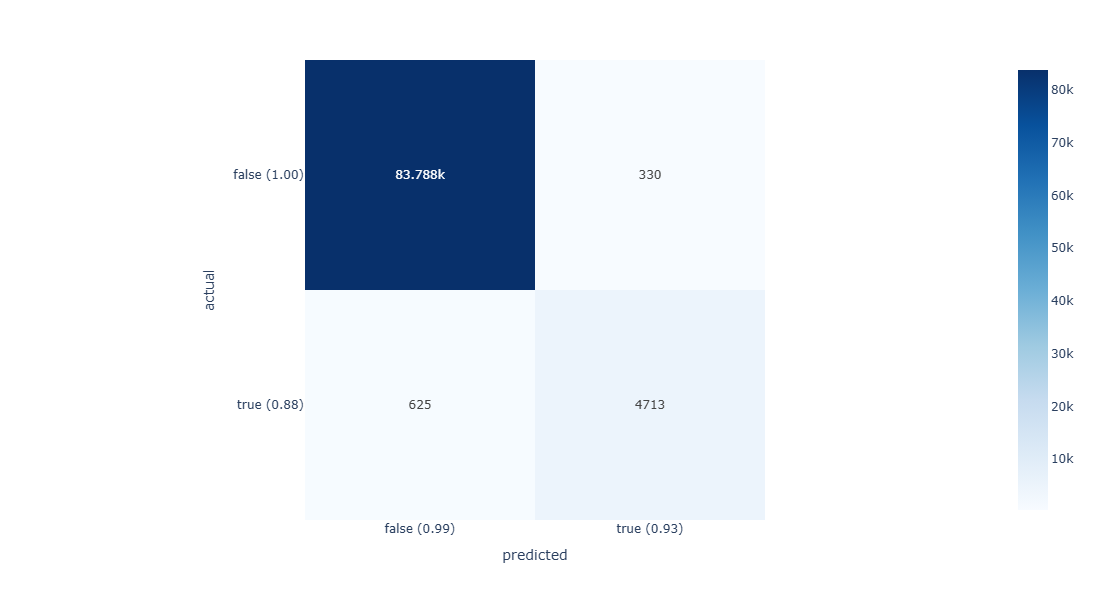

In [17]:
cm = confusion_matrix(y_test.to_numpy(dtype=int), y_pred.argmax(1))#
print(cm)

PX.displayConfusionMatrix(cm, xaxes={'labels': labels, 'title': 'predicted'}, yaxes={'labels': labels, 'title': 'actual'})

# 768 1/1
#[[83788   330]
# [  625  4713]]

### Sample

Prüfung der Vorhersage für Test-Daten anhand einzelner Beispiele.

Tatsächlichen Label sowie die durch das Modell vorhergesagten Label ausgeben.

In [35]:
index = 10

#X_test.iloc[:index]
print('actual')
print(y_test.iloc[:index].astype('int').tolist())
print('predict')
print(yp[:index].argmax(1).tolist())

actual
[0, 0, 0, 0, 0, 1, 0, 0, 1, 0]
predict
[0, 0, 0, 0, 0, 1, 0, 0, 1, 0]


### Stats

In [29]:
print('Training')
print(f'accuracy mean: {np.mean(history.history["accuracy"])},  min: {np.min(history.history["accuracy"])} max: {np.max(history.history["accuracy"])}')
print(f'loss mean: {np.mean(history.history["loss"])},  min: {np.min(history.history["loss"])} max: {np.max(history.history["loss"])}')
#print('Evaluierung')
#print(f'val_accuracy mean: {np.mean(history.history["val_accuracy"])},  min: {np.min(history.history["val_accuracy"])} max: {np.max(history.history["val_accuracy"])}')
#print(f'val_loss mean: {np.mean(history.history["val_loss"])},  min: {np.min(history.history["val_loss"])} max: {np.max(history.history["val_loss"])}')

Training
accuracy mean: 0.9880566596984863,  min: 0.9813497066497803 max: 0.9925764203071594
loss mean: 0.037057542552550636,  min: 0.02261911891400814 max: 0.05786731466650963


#### Box-Plot accuracy+loss

Darstellung von Trainings- und Evaluierungs- accuracy und loss für Epochen als Box-Plot

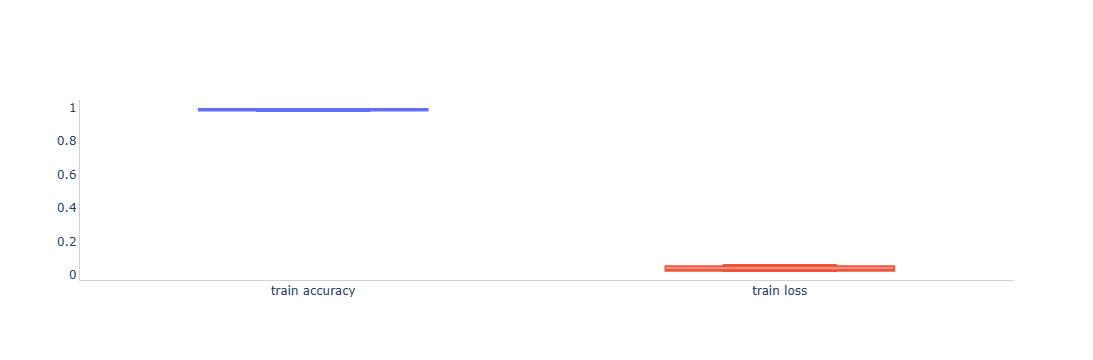

In [30]:
fig = go.Figure()

fig.add_trace(go.Box(
    y=history.history['accuracy'],
    name='train accuracy'
))

fig.add_trace(go.Box(
    y=history.history['loss'],
    name='train loss'
))

"""fig.add_trace(go.Box(
    y=history.history['val_accuracy'],
    name='val accuracy'
))

fig.add_trace(go.Box(
    y=history.history['val_loss'],
    name='val loss'
))"""
    
fig.update_yaxes(showgrid=False, showline=True, linewidth=1, linecolor='LightGrey', title='')
fig.update_xaxes(showline=True, linewidth=1, linecolor='LightGrey', title='')

fig.update_layout(plot_bgcolor='rgba(0, 0, 0, 0)', 
                  paper_bgcolor='rgba(0, 0, 0, 0)', 
                  #margin={'l':0, 'b':0, 'r':0, 't':0},
                  showlegend=False)#

fig.show()

#### Scatter Line-Plot accuracy+loss

Darstellung von Trainings- und Evaluierungs- accuracy und loss für Epochen als Scatter Line-Plot

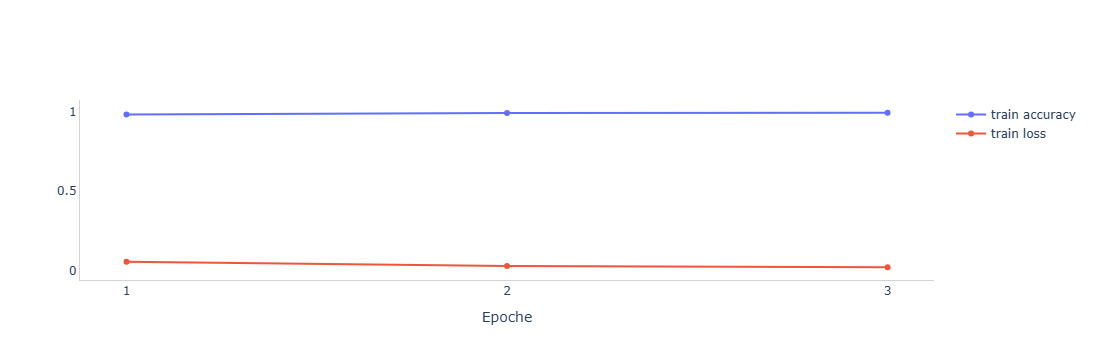

In [31]:
epochs = 3

fig = go.Figure()

fig.add_trace(go.Scatter(x=list(range(1, epochs + 1)), 
    y=history.history['accuracy'], 
    name='train accuracy',
    mode='lines+markers')
)

fig.add_trace(go.Scatter(x=list(range(1, epochs + 1)), 
    y=history.history['loss'], 
    name='train loss',
    mode='lines+markers')
)

"""fig.add_trace(go.Scatter(x=list(range(1, epochs + 1)), 
    y=history.history['val_accuracy'], 
    name='val accuracy',
    mode='lines+markers')
)

fig.add_trace(go.Scatter(x=list(range(1, epochs + 1)), 
    y=history.history['val_loss'], 
    name='val loss',
    mode='lines+markers')
)"""

fig.update_yaxes(showline=True, linewidth=1, linecolor='LightGrey', showgrid=False, title='')#, range=[0,epochs]
fig.update_xaxes(showline=True, linewidth=1, linecolor='LightGrey', showgrid=False, dtick = 1, title='Epoche')#

fig.update_layout(plot_bgcolor='rgba(0, 0, 0, 0)', 
paper_bgcolor='rgba(0, 0, 0, 0)', 
#margin={'l':0, 'b':0, 'r':0, 't':0},
title='',
showlegend=True)#

fig.show()